# Scikit Learn Week 10 - Joshua Lewi (2473018)

## 12. Logistic Regression pada Binary Classification Task

In [1]:
#Simple Linear Regression
#y = a (alpha) + b*x (beta)
#g(x) = a + b*x

#Multiple Linear Regression
#y = a (alpha) + b1*x1 (beta1) + b2*x2 (beta2) + ... + bn*xn (betan)
#g(X) = a + bX (X besar = merepresentasikan sejumlah features)

#Logistic Regression
#g(X) = sigmoid(a (alpha) + bX (betaX))
#sigmoid(x) = 1 / (1 + e^(-x)) (e^ = eksponensial)

#nilai Y sigmoid berada di antara 0 dan 1, sehingga cocok untuk klasifikasi biner (misalnya, apakah email itu spam atau tidak spam).
#rentang nilai Y sigmoid antara 0 dan 1 berkorelasi dengan binomial probability, yang membuatnya sangat berguna untuk masalah klasifikasi biner.

In [5]:
#Dataset SMS Spam Collection Data Set
import pandas as pd
df = pd.read_csv('SMSSpamCollection',
                 sep='\t',
                 header=None,
                 names=['label', 'sms'])
df.head()

,label,sms
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [6]:
df['label'].value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

In [7]:
from sklearn.preprocessing import LabelBinarizer

X = df['sms'].values
y = df['label'].values

lb = LabelBinarizer()
y = lb.fit_transform(y).ravel()
lb.classes_

array(['ham', 'spam'], dtype='<U4')

In [8]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y, 
                                                    test_size=0.2, 
                                                    random_state=0)

print(X_train, '\n')
print(y_train)

["No I'm good for the movie, is it ok if I leave in an hourish?"
 'If you were/are free i can give. Otherwise nalla adi entey nattil kittum'
 'Have you emigrated or something? Ok maybe 5.30 was a bit hopeful...' ...
 "For ur chance to win a £250 cash every wk TXT: ACTION to 80608. T's&C's www.movietrivia.tv custcare 08712405022, 1x150p/wk"
 'R U &SAM P IN EACHOTHER. IF WE MEET WE CAN GO 2 MY HOUSE'
 'Mm feeling sleepy. today itself i shall get that dear'] 

[0 0 0 ... 1 0 0]


In [9]:
#Feature Extraction dengan TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words='english')

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(X_train_tfidf)

  (0, 3106)	0.30778739607068667
  (0, 4491)	0.4933198981059812
  (0, 4781)	0.2937599690543961
  (0, 3965)	0.40459749284424307
  (0, 3427)	0.6418008618863358
  (1, 2907)	0.21207121889209815
  (1, 4560)	0.42053679904641994
  (1, 818)	0.44107102567653744
  (1, 2539)	0.44107102567653744
  (1, 4579)	0.44107102567653744
  (1, 3860)	0.44107102567653744
  (2, 4781)	0.2349500626979615
  (2, 2508)	0.5133141633463273
  (2, 4299)	0.36445133334144264
  (2, 435)	0.4077104256374456
  (2, 1322)	0.34462014146959175
  (2, 3403)	0.5133141633463273
  (3, 3783)	0.3134261626040451
  (3, 3123)	0.3618429196578873
  (3, 3383)	0.3853995778343805
  (3, 1165)	0.44847242609346283
  (3, 1142)	0.6489787288715116
  (4, 3810)	1.0
  (5, 7386)	0.7984426989330436
  (5, 3736)	0.6020708068994186
  :	:
  (4454, 7016)	0.14040083857773877
  (4454, 1670)	0.21130971337962476
  (4454, 7316)	0.1949753381818719
  (4454, 1626)	0.18784292855815676
  (4454, 6907)	0.21937394005137992
  (4454, 6916)	0.1653057679612594
  (4454, 7348)	0.

In [10]:
#Binary Classification dengan Logistic Regression
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train_tfidf, y_train)
y_pred = model.predict(X_test_tfidf)

for pred, sms in zip(y_pred[:5], X_test[:5]):
    print(f'PRED (Predicted): {pred} - SMS: {sms}\n')

PRED (Predicted): 0 - SMS: Storming msg: Wen u lift d phne, u say "HELLO" Do u knw wt is d real meaning of HELLO?? . . . It's d name of a girl..! . . . Yes.. And u knw who is dat girl?? "Margaret Hello" She is d girlfrnd f Grahmbell who invnted telphone... . . . . Moral:One can 4get d name of a person, bt not his girlfrnd... G o o d n i g h t . . .@

PRED (Predicted): 0 - SMS: <Forwarded from 448712404000>Please CALL 08712404000 immediately as there is an urgent message waiting for you.

PRED (Predicted): 0 - SMS: And also I've sorta blown him off a couple times recently so id rather not text him out of the blue looking for weed

PRED (Predicted): 0 - SMS: Sir Goodmorning, Once free call me.

PRED (Predicted): 0 - SMS: All will come alive.better correct any good looking figure there itself..



### Evaluation Metrics pada Binary Classification
* Confusion Matrix
* Accuracy
* Precission & Recall
* F1 Score
* ROC

##### Terkait evaluation Metrics pada Binary Classification, terdapat 4 terminologi dasar

### Terminologi Dasar
* True Positive (TP) - (Benar) Bernilai Positif, diprediksi oleh model (ham/spam)
* True Negative (TN) - (Benar) Bernilai negatif, diprediksi oleh model (bukan ham/spam)
* False Positive (FP) - (Keliru) Bernilai positif, diprediksi oleh model (ham jadi spam, spam jadi ham)
* False Negative (FN) - (Keliru) Bernilai negatif, diprediksi oleh model (Ham jadi bukan ham, Spam jadi bukan spam)

In [11]:
#Confusion Matrix

from sklearn.metrics import confusion_matrix
matrix = confusion_matrix(y_test, y_pred)
matrix

array([[954,   1],
       [ 36, 124]], dtype=int64)

In [12]:
tn, fp, fn, tp = matrix.ravel()

print(f'TN: {tn}')
print(f'FP: {fp}')
print(f'FN: {fn}')
print(f'TP: {tp}')

TN: 954
FP: 1
FN: 36
TP: 124


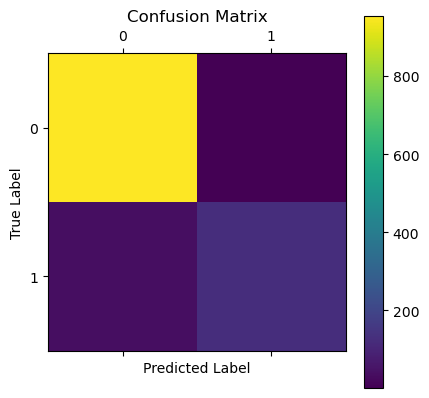

In [13]:
import matplotlib.pyplot as plt

plt.matshow(matrix)
plt.colorbar()

plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [14]:
#Accuracy
#Accuracy mengukur porsi dari hasil prediksi yang tepat
#Accuracy = (TP + TN) / (TP + TN + FP + FN) = correct/total

from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.9668161434977578

In [15]:
#Precission & Recall

#Selain menggunakan accuracy, performa dari suatu classifier
#umumnya juga diukur berdasarkan nilai Precission dan Recall.

#Precission or Positive Predictive Value (PPV)
#Precission = TP / (TP + FP) = benar positif / semua yang diprediksi positif    

In [16]:
from sklearn.metrics import precision_score

precision_score(y_test, y_pred)

0.992

In [17]:
#Recall or True Positive Rate (TPR) or Sensitivity
#Recall = TP / (TP + FN) = benar positif / semua yang sebenarnya positif
from sklearn.metrics import recall_score

recall_score(y_test, y_pred)

0.775

In [18]:
#F1 Score
#F1 Score/Measure adalah harmonic mean dari Precission dan Recall
#F1 Score = (Precission * Recall) / (Precission + Recall)

from sklearn.metrics import f1_score
f1_score(y_test, y_pred)

0.8701754385964913

In [19]:
#ROC =: Receiver Operating Characteristic
#ROC Menawarkan visualisasi terhadap performa dari classifier dengan
#membandingkan nilai Recall (TPR) dan False Positive Rate (FPR) atau Fallout

#Fallout = FP / (FP + TN) = salah positif / semua yang sebenarnya negatif

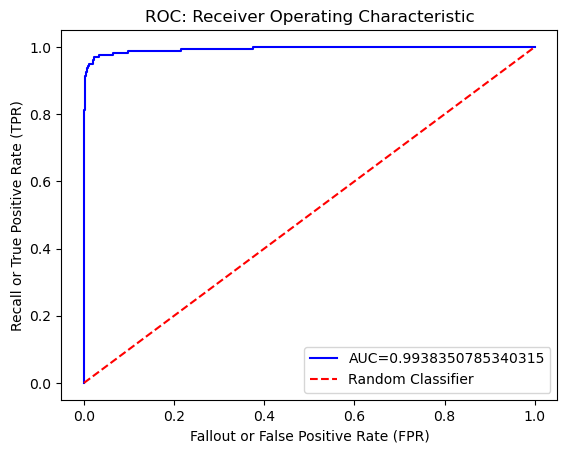

In [21]:
from sklearn.metrics import roc_curve, auc

prob_estimates = model.predict_proba(X_test_tfidf)
fpr, tpr, threshold = roc_curve(y_test, prob_estimates[:, 1])
nilai_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, 'b', label=f'AUC={nilai_auc}')
plt.plot([0,1], [0,1], 'r--', label='Random Classifier')  #Garis diagonal untuk referensi

plt.title('ROC: Receiver Operating Characteristic')
plt.xlabel('Fallout or False Positive Rate (FPR)')
plt.ylabel('Recall or True Positive Rate (TPR)')
plt.legend()
plt.show()